# L6d Extra: Synthetic Data Diagnostics (Optional)
This optional notebook contains the exploratory "Extra" analysis moved out of the main L6d lab. If you have time, use this notebook to generate synthetic return paths and compare distribution and autocorrelation diagnostics.
___


## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Environment Setup__
> 
> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/).

Let's set up our code environment. The code block below returns `nothing::Nothing` and applies side effects by evaluating `Include.jl` in global scope.


In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we'll also use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl). Check out [the documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/) for more information on the functions, types, and data used in this material.

### Data
We gathered a daily open-high-low-close `dataset` for each firm in the [S&P500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for a few exchange-traded funds and volatility products during that time.

Let's load `original_dataset::Dict{String,DataFrame}` by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and remove firms that do not have the maximum number of trading days. The cleaned dataset $\mathcal{D}$ will be stored in `dataset::Dict{String,DataFrame}`.

The code block below returns `original_dataset::Dict{String,DataFrame}`, where each key is a ticker symbol and each value is that ticker's historical market dataframe.


In [2]:
original_dataset = MyTrainingMarketDataSet() |> x -> x["dataset"]; # load the original dataset

Not all tickers in our dataset have the maximum number of trading days for various reasons, e.g., acquisition or de-listing events. Let's collect only those tickers with the maximum number of trading days.

First, let's compute the number of records for a firm that we know has a maximum value, e.g., `AAPL`, and save that value in `maximum_number_trading_days::Int64`. The code block below returns `maximum_number_trading_days::Int64`, which is the reference row count used to filter ticker histories.


In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow # nrow? (check out: DataFrames.jl)

2767

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in `dataset::Dict{String,DataFrame}`. The code block below returns `dataset::Dict{String,DataFrame}`, which stores only full-length ticker histories.

In [4]:
dataset = let

    # initialize -
    dataset = Dict{String, DataFrame}();

    # iterate through the dictionary; we can't guarantee a particular order
    for (ticker, data) ∈ original_dataset  # we get each (K, V) pair!
        if (nrow(data) == maximum_number_trading_days) # what is this doing?
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Finally, let's get a list of the firms in our cleaned dataset (sorted alphabetically). We store the symbols in `list_of_tickers::Vector{String}`. The code block below returns `list_of_tickers::Vector{String}`, where each element is one ticker symbol.

In [5]:
list_of_tickers = keys(dataset) |> collect |> sort # list of firm "ticker" symbols in alphabetical order

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 ⋮
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

## Task 1: Compute the growth rate matrix
In this task, we compute the growth rate array which contains, for each day and each firm in our dataset, the value of the growth rate between time $j$ and $j-1$.

> __Continuously Compounded Growth Rate (CCGR):__
> 
> The daily price update for firm $i$ can be written using a continuously compounded return term.
> $$
\begin{align*}
S^{(i)}_{j} &= S^{(i)}_{j-1}\;\exp\left(\underbrace{g^{(i)}_{j,j-1}\Delta t_{j}}_{\text{return}}\right)
\end{align*}
> $$
> Here, $S^{(i)}_{j-1}$ is the price at time index $j-1$, $S^{(i)}_{j}$ is the price at time index $j$, and $\Delta t_{j}=t_j-t_{j-1}$ is the step length in years. The quantity we estimate from data is the return term $g^{(i)}_{j,j-1}\Delta t_{j}$. We've implemented [the `log_growth_rate(...)` function](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/data/#VLDataScienceMachineLearningPackage.log_growth_matrix) which takes the cleaned up dataset and a list of ticker symbols and returns the growth rate array.

The code block below returns `G::Matrix{Float64}`, where each row is a trading day and each column is a ticker growth rate.


In [6]:
G = let

    # initialize -
    r̄ = 0.0; # assume the risk-free rate is 0
    Δt = (1/252); # time step size (units: years)

    # compute the growth matrix -
    growth_rate_array = log_growth_matrix(dataset, list_of_tickers, Δt = Δt, 
        risk_free_rate = r̄); # other optional parameters are at their defaults
    
    growth_rate_array; # return
end;

In this application, the memory vectors we load are daily growth-rate vectors across all firms in the dataset, so each memory is one market day across tickers. Let's scale the data to have zero mean and unit length.

The code block below returns `(memories::Matrix{Float64}, scaled_memories::Matrix{Float64})`. The matrix `memories` stores raw daily vectors on columns, and `scaled_memories` stores centered, unit-norm versions of those same columns.


In [7]:
memories, scaled_memories = let

    # initialize -
    ϵ = 1e-12; # small number to avoid division by zero
    memories = transpose(G) |> Matrix; # each column is a memory vector (day in the market), and each row is a feature (a firm in the dataset)
    (number_of_rows, number_of_columns) = size(memories); # get the dimensions of the memories array

    # scale the memories to have zero-mean, and unit length
    scaled_memories = zeros(number_of_rows, number_of_columns);
    for i in 1:number_of_columns
        memory = memories[:,i]; # unscaled memory vector (day in the market)
        mean_memory = mean(memory); # what was the mean value for the growth rate that day (across all firms)?
        memory_centered = memory .- mean_memory; # center the memory vector by subtracting the mean value
        norm_memory_centered = norm(memory_centered) + ϵ; # compute the norm of the centered memory vector, and add a small number to avoid division by zero
        scaled_memories[:,i] = memory_centered ./ (norm_memory_centered + ϵ); # scale the memory vector to have unit length
    end
   
    # return -
    (memories, scaled_memories);
end;

## Task 2: Let's run the Hopfield model in generative mode
In this task, we'll run the modern Hopfield network in generative mode, i.e., with $\beta\ll{1}$ (high temperature, which means more stochastic behavior). We'll give the model a random vector as input and generate a weighted combination of stored memories.

The code block below returns `generative_model::MyModernHopfieldNetworkModel`, which is the low-$\beta$ model instance used for synthesis.


In [8]:
generative_model = build(MyModernHopfieldNetworkModel, (
    memories = memories, # raw memories on columns
    normalized_memories = scaled_memories, # normalized memories on columns
    β = 0.3, # small beta -> high temperature -> diffuse probabilities (generative mode)
));

For generative mode, we will *not* start from a known day. Instead, we use a random query vector as the initial state and let the model produce a probability distribution over stored memories. When this probability vector is diffuse, we can optionally project it to a top-`k` support (and renormalize) before forming a weighted memory, which reduces cancellation from near-uniform averaging.

> __What is going on in the code block below?__
> 
> We draw a random seed vector $s\in\mathbb{R}^{N}$ with independent entries $s_i\sim Z(0,1)$, where $N$ is the number of firms/features. We then normalize and rescale this vector using $\tilde{s}=\frac{s}{\|s\|_2+\epsilon}$ and $\hat{s}_2=\alpha\tilde{s}$, where $\alpha=\frac{1}{K}\sum_{j=1}^{K}\|m_j\|_2$ is the average norm of the stored memories. 
> 
> This gives a query with a realistic magnitude but no direct match to any specific market day, which is what we want in generative mode: under low $\beta$, the model can evolve toward a diffuse probability mixture over memories instead of trivially retrieving one day.

The code block below returns `ŝ₂::Vector{Float64}`, the random initial query used in __generative mode__.


In [9]:
ŝ₂ = let

    # Build a random query with a comparable scale to the stored market memories
    
    # initialize -
    number_of_features = size(memories, 1); # how many firms (features) do we have in our dataset?
    target_norm = mean(norm(memories[:, i]) for i ∈ 1:size(memories, 2)); # "scale" of the memories (average norm of the memory vectors)
    
    # create a radom vector with the same number of features as the memories, and a norm comparable to the memories
    s = randn(number_of_features); # random vector, standard normal distribution
    s ./= (norm(s) + 1e-12); # normalize the random vector to have unit length (add a small number to avoid division by zero)
    s .*= target_norm; # scale the random vector to have a norm comparable to the memories

    s; # return the random query vector
end;

### Let's generate synthetic market data
If this works, we should be able to generate return trajectories for assets in the network that have realistic statistical structure. Let's compare generated and observed data.

First, let's generate synthetic data by iterating the generative process above.

The code block below returns `Ĝ::Matrix{Float64}` with dimensions `(number_of_synthetic_days, number_of_synthetic_firms)`, where each row is one synthetic day and each column is one ticker.

In [10]:
Ĝ = let

    # initialize -
    number_of_synthetic_days = maximum_number_trading_days; # how many synthetic days to generate
    number_of_synthetic_firms = length(list_of_tickers); # number of firms (features)
    sₒ = ŝ₂; # initial query state
    Ĝ = Array{Float64,2}(undef, number_of_synthetic_days, number_of_synthetic_firms);

    # memory-mixture controls -
    k = 25; # top-k support for memory mixing
    γ_sharpen = 4.0; # sharpen q to reduce over-smoothing
    λ_q = 0.00; # keep near 0 to avoid strong raw-return autocorrelation
    σ_select = 1e-5; # small jitter for stochastic tie-breaking in top-k

    # query-state controls -
    λ_query = 0.00; # keep near 0 for weak raw-return autocorrelation
    σ_query = 0.10; # additive noise in query evolution

    # latent volatility state h_t (AR(1) in log-vol) -
    ρ_logh = 0.98; # volatility persistence
    σ_logh = 0.30; # volatility shock scale (increase for stronger clustering)
    logh = 0.0;

    # optional post-adjustments -
    match_ticker_means = true;  # shift generated per-ticker means to match original means
    match_ticker_stds = true;  # keep false when evaluating volatility clustering
    α_std = 1.0; # partial std scaling if match_ticker_stds=true

    # constants -
    M = memories; # raw memories on columns (features x memory_index)
    number_of_memories = size(M, 2);
    μ_orig = vec(mean(G, dims=1));
    σ_orig = vec(std(G, dims=1));
    q_prev = fill(1.0/number_of_memories, number_of_memories);

    for t ∈ 1:number_of_synthetic_days

        # recover probabilities over memories from current query
        (m̂, f, p) = recover(generative_model, sₒ, maxiterations = 100, ϵₚ = 1e-12, ϵₛ = 5e-1);
        last_probability = p[length(f) - 1];

        # stochastic top-k proposal q_new
        selection_scores = last_probability .+ σ_select*randn(length(last_probability));
        sorted_idx = sortperm(selection_scores, rev=true);
        keep = sorted_idx[1:min(k, length(sorted_idx))];

        q_new = zeros(length(last_probability));
        q_new[keep] = last_probability[keep];
        q_new ./= (sum(q_new) + 1e-12);

        # sticky mixture weights for temporal persistence
        q = λ_q*q_prev + (1 - λ_q)*q_new;
        q ./= (sum(q) + 1e-12);

        # sharpen then renormalize
        q .^= γ_sharpen;
        q ./= (sum(q) + 1e-12);

        # base generated vector from memory mixture
        m_raw = M*q;

        # latent volatility update: log h_t = ρ log h_{t-1} + σ ε_t
        logh = ρ_logh*logh + σ_logh*randn();
        h = exp(logh);

        # apply scalar volatility modulation around per-ticker historical mean
        m_topk = μ_orig .+ sqrt(h).*(m_raw .- μ_orig);

        # store generated day
        Ĝ[t, :] = m_topk;

        # evolve query state with persistence + noise (do not hard-normalize)
        sₒ = λ_query*sₒ + (1 - λ_query)*m_topk + σ_query*randn(length(m_topk));

        # carry state
        q_prev = q;
    end

    # optional first/second-moment matching per ticker
    if match_ticker_means || match_ticker_stds
        μ_gen = vec(mean(Ĝ, dims=1));
        σ_gen = vec(std(Ĝ, dims=1));

        if match_ticker_stds
            scale = (σ_orig ./ (σ_gen .+ 1e-12)) .^ α_std;
            Ĝ .-= reshape(μ_gen, 1, :);
            Ĝ .*= reshape(scale, 1, :);
            Ĝ .+= reshape(μ_orig, 1, :);
        elseif match_ticker_means
            Ĝ .+= reshape(μ_orig .- μ_gen, 1, :);
        end
    end

    println("Generated days: ", number_of_synthetic_days, ", unique rows (rounded 1e-10): ", length(unique(eachrow(round.(Ĝ, digits=10)))));
    println("Mean alignment check (avg |Δμ|): ", mean(abs.(vec(mean(Ĝ, dims=1)) .- μ_orig)));
    println("Std alignment check (avg |Δσ|): ", mean(abs.(vec(std(Ĝ, dims=1)) .- σ_orig)), " (α_std = ", α_std, ")");

    Ĝ;
end

Generated days: 2767, unique rows (rounded 1e-10): 2767
Mean alignment check (avg |Δμ|): 7.333588882872521e-17
Std alignment check (avg |Δσ|): 3.0922078315089527e-12 (α_std = 1.0)


2767×424 Matrix{Float64}:
 -2.98868     -2.18955     2.7299    …  -4.5423      -3.31236    0.0210032
  1.83516      6.0731      2.01495       4.24719      4.52592   -1.70966
  1.41789      9.52861     6.16431       1.55933      6.93064    1.88498
  0.916829     4.30765     0.161599      0.812097     1.64487    1.49359
 -0.156608    -2.2604      0.442733      3.31666     -0.112303  -1.61532
 -3.48544      0.583974    2.03602   …  -1.11348     -4.72228   -1.16319
  3.1034       0.328117    1.0319        2.60748      2.4613     2.10824
 -0.326814    -2.34761    -0.941064     -1.25782      1.85525   -1.95773
 -3.42427      6.081      -3.95443       2.80873      3.15394   -1.31948
  0.550139     1.03478     4.80482      -1.02007      1.53795    2.33994
  ⋮                                  ⋱                          
  3.03285     -3.04582    -2.92379      -0.543831    -1.21005   -4.60458
  2.77029     -2.62936    -0.881618     -2.14207     -2.80243    2.29908
 -0.359669    -0.0591693   3.68

## Task 3: Let's compute the Stylized Facts for our synthetic data
In this task, we will compute stylized facts for our synthetic data and compare them to the original data. Stylized facts are empirical observations about the statistical properties of financial returns that hold across different markets and time periods. 

Analysts and investors gain insights into market behavior, risk, and investment opportunities by examining returns and their properties (stylized facts). While several stylized facts have been developed, let’s consider the following:

* __Heavy (also called fat) tailed distribution__: Stock returns often exhibit a distribution with fatter tails than would be expected under a normal distribution. This means that extreme price movements are more likely than would be predicted by a normal distribution.
* __Absence of Autocorrelation__: Autocorrelation refers to the tendency of stock returns to correlate with past returns over time. Autocorrelation suggests predictability in returns, which traders could exploit. On the other hand, a random walk is uncorrelated with itself. We expect a random walk with occasional jumps.
* __Volatility clustering__: Stock returns tend to be more volatile during specific periods and less volatile during others. This phenomenon is known as volatility clustering, suggesting that large price movements are more likely to be followed by other large moves, and other small moves follow small moves.

These are not the only stylized facts of equity returns, but they are among the most widely recognized and studied. For more details, see the following references:
* Cont, R. (2001). Empirical properties of asset returns: stylized facts and statistical issues. *Quantitative Finance*, 1(2), 223-236. [Link](https://doi.org/10.1080/713665670)
* Mandelbrot, B. (1963). The Variation of Certain Speculative Prices. The Journal of Business, 36(4), 394–419. [Link](http://www.jstor.org/stable/2350970)

Let's look at three stylized facts for our synthetic data and compare them to the original data. We will look at the distribution of returns, the autocorrelation of returns, and the autocorrelation of absolute returns (which is a proxy for volatility clustering).

Let's start by looking at a specific ticker and compare generated data to original data. We'll specify the ticker we care about in the  `ticker_to_compare::String`:

In [11]:
ticker_to_compare = "AAPL"; # which ticker do we want to compare between the original and generated data?

### Heavy Tailed Return Distributions
Heavy‐tailed distributions have probability of extreme deviations that decays more slowly than exponentially, making large shocks rarer but much more likely than under a normal distribution. 

Let's look at the distribution of returns for our synthetic data and compare it to the original data. We can visualize this by plotting histograms or kernel density estimates of the returns for a specific ticker.

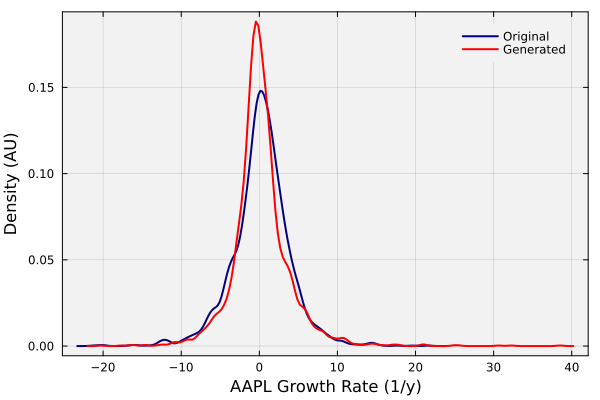

In [18]:
let

    # initialize -
    ticker_index = findfirst(==(ticker_to_compare), list_of_tickers); # find the index of the ticker we want to compare

    # let's plot the return distribution -
    density(G[:, ticker_index], label="Original", xlabel="$(ticker_to_compare) Growth Rate (1/y)", ylabel="Density (AU)",
        color=:navy, lw=2)
    density!(Ĝ[:, ticker_index], label="Generated", color=:red, lw=2)

    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent)
end

### Auto-correlation structure of the generated data
Let's check if the generated data has a similar auto-correlation structure to the original data by comparing observed and generated autocorrelation curves.

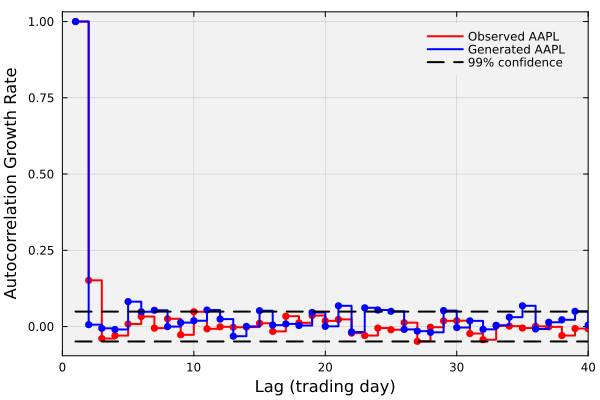

In [13]:
let

    # generate a random index -
    i = findfirst(ticker -> ticker == ticker_to_compare,list_of_tickers);
    number_of_steps = maximum_number_trading_days - 1;
    max_number_of_steps_x = 40
    X = G[:,i]; # TODO: change to Ĝ to compare the generated data instead of the original data
    X̂ = Ĝ[:,i]; # this is the generated data for the same ticker
    
    # Observed autocorrelation for the original data
    plot(autocor(X, (0:(number_of_steps - 1) |> collect)), label="Observed $(ticker_to_compare)", lw=2, c=:red, 
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, 
        linetype=:steppost, xlims=(0,max_number_of_steps_x))
    scatter!(autocor(X, (0:(number_of_steps - 1) |> collect)), label="", c=:red, msc=:red)
    
    # Autocorrelation for the generated data
    plot!(autocor(X̂, (0:(number_of_steps - 1) |> collect)), label="Generated $(ticker_to_compare)", lw=2, c=:blue, linetype=:steppost)
    scatter!(autocor(X̂, (0:(number_of_steps - 1) |> collect)), label="", c=:blue, msc=:blue)
    
    # Confidence intervals for null hypothesis of no autocorrelation (dashed lines)
    LINE = (2.576/sqrt(number_of_steps))*ones(number_of_steps-1);
    plot!(LINE, label="99% confidence", lw=2, c=:black, ls=:dash)
    plot!(-LINE, label="", lw=2, c=:black, ls=:dash)
    xlabel!("Lag (trading day)", fontsize=18)
    ylabel!("Autocorrelation Growth Rate", fontsize=18)

    # uncomment me to save to file -
    # savefig(joinpath(_PATH_TO_FIGS, "Fig-Autocorrelation-HMM-GenModel-$(ticker_to_compare).pdf"));
end

### Volatility clustering
Finally, let's consider volatility clustering. Volatility clustering is determined by examining autocorrelation of squared returns at different lags.

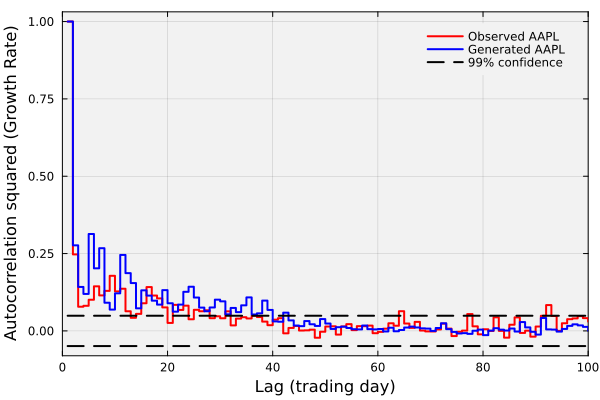

In [14]:
let

    # generate a random index -
    i = findfirst(ticker -> ticker == ticker_to_compare,list_of_tickers);
    number_of_steps = maximum_number_trading_days - 1;
    max_number_of_steps_x = 100
    X = (G[:,i]).^2;
    X̂ = (Ĝ[:,i]).^2;

    plot(autocor(X, (0:(number_of_steps - 1) |> collect)), label="Observed $(ticker_to_compare)", lw=2, c=:red,
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, linetype=:steppost,
    xlims=(0,max_number_of_steps_x))

    plot!(autocor(X̂, (0:(number_of_steps - 1) |> collect)), label="Generated $(ticker_to_compare)", lw=2, c=:blue,
        bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent, linetype=:steppost,
    xlims=(0,max_number_of_steps_x))
    
    LINE = (2.576/sqrt(number_of_steps))*ones(number_of_steps-1);
    plot!(LINE, label="99% confidence", lw=2, c=:black, ls=:dash)
    plot!(-LINE, label="", lw=2, c=:black, ls=:dash)
    xlabel!("Lag (trading day)", fontsize=18)
    ylabel!("Autocorrelation squared (Growth Rate)", fontsize=18)

    
    # uncomment me to save to file -
    # savefig(joinpath(_PATH_TO_FIGS, "Fig-Autocorrelation-HMM-GenModel-$(ticker_to_compare).pdf"));
end